In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage.filters import gaussian_filter1d
import itertools
import math
import copy
import ptitprince as pt

PYTHON_PATH = "/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/altricial_brain_vocal_learning"

/var/folders/ys/4vmt6skn47v69q7dptm_7p3m0000gp/T/ipykernel_19174/4175656451.py:5: DeprecationWarning: Please use `gaussian_filter1d` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter1d


In [2]:
# Define the growth functions
def growth_Gompertz(t, k, t0, L):
    """
    Gompertz growth function.
    A normalized growth function that starts at 0 and ends at L (maximum value).
    t: time
    k: growth rate
    t0: midpoint of the growth
    L: maximum value (carrying capacity)
    """
    return L * np.exp(-np.exp(-k * (t - t0)))

def growth_rate_Gompertz(t, k, t0, L):
    """
    Gompertz growth rate function.
    The derivative of the normalized growth function.
    t: time
    k: growth rate
    t0: midpoint of the growth
    L: maximum value (carrying capacity)
    """
    #gompertz = growth_Gompertz(t, k, t0, L)
    #return L * k * gompertz * np.exp(-k * (t - t0))
    return L * np.exp(-np.exp(-k * (t - t0))) * np.exp(-k * (t - t0)) * k


def growth_logistic(t, k, t0, L):
    """
    A normalized growth function that starts at 0 and ends at L (maximum value).
    t: time
    k: growth rate
    t0: midpoint of the growth
    L: maximum value (carrying capacity)
    """
    return L / (1 + np.exp(-k * (t - t0)))


def growth_rate_logistic(t, k, t0, L):
    """
    The derivative of the normalized growth function.
    t: time
    k: growth rate
    t0: midpoint of the growth
    L: maximum value (carrying capacity)
    """
    growth = growth_logistic(t, k, t0, L)
    return k * growth * (1 - growth / L)


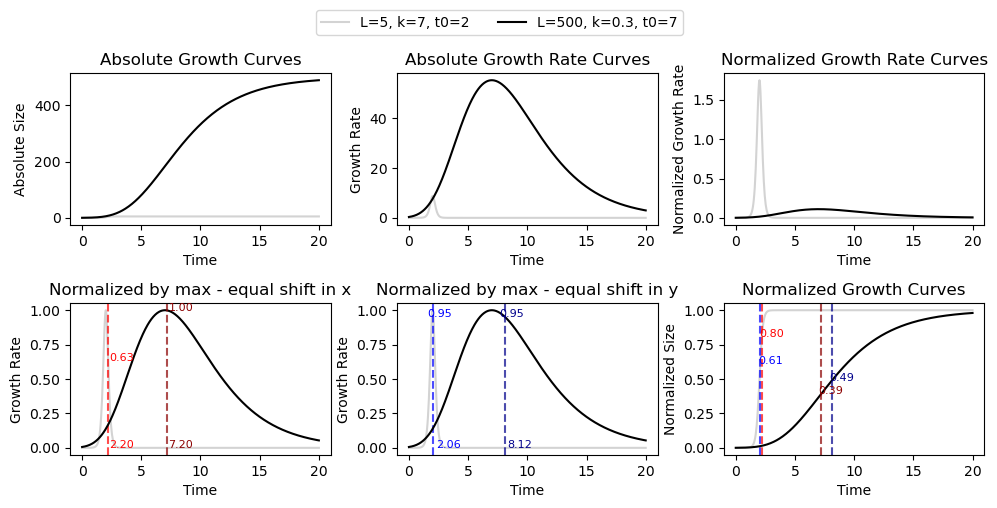

In [3]:
# Define parameters for the growth function
L_k_t0_combinations = [(5, 7, 2,"lightgrey",growth_logistic,growth_rate_logistic), 
                       (500, 0.3, 7,"black",growth_Gompertz,growth_rate_Gompertz)]  # Combinations of L, k, and t0, color, birth time

# Generate time points
t = np.linspace(0, 20, 500)

#Plot
# Create a figure with 4 subplots
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))

# Plot the absolute growth curves (left column, top)
for L, k, t0, color, growth_func, deriv_func in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = growth_func(t, k, t0, L)
    ax[0, 0].plot(t, y, color = color, label=f'L={L}, k={k}, t0={t0}')
    #t_birth = t0 + t_birth_delay  # Calculate the birth time based on t0 and delay
    #ax[0, 0].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)


# Plot the absolute growth rate curves (left column, bottom)
for L, k, t0, color, growth_func, deriv_func in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = deriv_func(t, k, t0, L)
    ax[0, 1].plot(t, y, color = color,label=f'L={L}, k={k}, t0={t0}')
    #t_birth = t0 + t_birth_delay  # Calculate the birth time based on t0 and delay
    #ax[0, 1].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Plot the normalized growth rate curves (right column, bottom)
for L, k, t0, color, growth_func, deriv_func in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = deriv_func(t, k, t0, L) / L  # Normalize by L
    ax[0, 2].plot(t, y,color = color, label=f'L={L}, k={k}, t0={t0}')
    #t_birth = t0 + t_birth_delay  # Calculate the birth time based on t0 and delay
    #ax[0, 2].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

birth_days = {"x_shift":[], "y_shift":[]}

#Same shift in x
t_birth_x_delay = 0.2
colors_shift_x = ["red","darkred"]
i = 0
for L, k, t0, color, growth_func, deriv_func in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = deriv_func(t, k, t0, L)/ np.max(deriv_func(t, k, t0, L))  # Normalize by max growth rate
    ax[1, 0].plot(t, y, color = color,label=f'L={L}, k={k}, t0={t0}')
    t_birth = t0 + t_birth_x_delay  # Calculate the birth time based on t0 and delay
    birth_days["x_shift"].append(t_birth)
    y_at_birth = deriv_func(t_birth, k, t0, L) / np.max(deriv_func(t, k, t0, L))
    ax[1, 0].text(t_birth + 0.1, y_at_birth, f'{y_at_birth:.2f}', color=colors_shift_x[i], fontsize=8)
    ax[1, 0].axvline(x=t_birth, color=colors_shift_x[i], linestyle='--', alpha=0.7)
    ax[1, 0].text(t_birth + 0.1, 0, f'{t_birth:.2f}', color=colors_shift_x[i], fontsize=8)

    i += 1

#Same shift in y
y_value_shift = 0.05
colors_shift_y = ["blue","darkblue"]
i = 0
for L, k, t0, color, growth_func, deriv_func in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = deriv_func(t, k, t0, L)/ np.max(deriv_func(t, k, t0, L))  # Normalize by max growth rate
    ax[1, 1].plot(t, y, color = color,label=f'L={L}, k={k}, t0={t0}')

    
    FOUND = False
    t_birth = t0 
    while not FOUND:
        t_birth += 0.001  # Calculate the birth time based on t0 and delay
        y_at_birth = deriv_func(t_birth, k, t0, L) / np.max(deriv_func(t, k, t0, L))
        distance_from_value = np.abs(1-y_value_shift - y_at_birth)

        if  distance_from_value < 0.001:
            ax[1, 1].text(t_birth - 0.5, y_at_birth, f'{y_at_birth:.2f}', color=colors_shift_y[i], fontsize=8)
            ax[1, 1].axvline(x=t_birth, color=colors_shift_y[i], linestyle='--', alpha=0.7)
            ax[1, 1].text(t_birth + 0.2, 0, f'{t_birth:.2f}', color=colors_shift_y[i], fontsize=8)
            birth_days["y_shift"].append(t_birth)
            FOUND = True
        
    i += 1


i = 0
# Plot the normalized growth curves (right column, top)
for L, k, t0, color, growth_func, deriv_func in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = growth_func(t, k, t0, L) / L  # Normalize by L
    ax[1, 2].plot(t, y,color = color, label=f'L={L}, k={k}, t0={t0}')


    t_birth = birth_days["x_shift"][i]  # Calculate the birth time based on t0 and delay
    ax[1, 2].axvline(x=t_birth, color=colors_shift_x[i], linestyle='--', alpha=0.7)
    y_at_birth = growth_func(t_birth, k, t0, L) / L
    ax[1, 2].text(t_birth - 0.2, y_at_birth, f'{y_at_birth:.2f}', color=colors_shift_x[i], fontsize=8)

    t_birth = birth_days["y_shift"][i]  # Calculate the birth time based on t0 and delay
    ax[1, 2].axvline(x=t_birth, color=colors_shift_y[i], linestyle='--', alpha=0.7)
    y_at_birth = growth_func(t_birth, k, t0, L) / L
    ax[1, 2].text(t_birth - 0.2, y_at_birth, f'{y_at_birth:.2f}', color=colors_shift_y[i], fontsize=8)

    i += 1

# Set titles and labels
ax[0, 0].set_title('Absolute Growth Curves')
ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Absolute Size')

ax[0, 1].set_title('Absolute Growth Rate Curves')
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('Growth Rate')

ax[0, 2].set_title('Normalized Growth Rate Curves')
ax[0, 2].set_xlabel('Time')
ax[0, 2].set_ylabel('Normalized Growth Rate')

ax[1, 0].set_title('Normalized by max - equal shift in x')
ax[1, 0].set_xlabel('Time')
ax[1, 0].set_ylabel('Growth Rate')

ax[1, 1].set_title('Normalized by max - equal shift in y')
ax[1, 1].set_xlabel('Time')
ax[1, 1].set_ylabel('Growth Rate')

ax[1, 2].set_title('Normalized Growth Curves')
ax[1, 2].set_xlabel('Time')
ax[1, 2].set_ylabel('Normalized Size')





# Add a single legend for the entire figure
handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the legend

# Save the figure
fig.savefig("{0}/figs/2D_E_F_G.pdf".format(PYTHON_PATH), dpi=800)

plt.show()

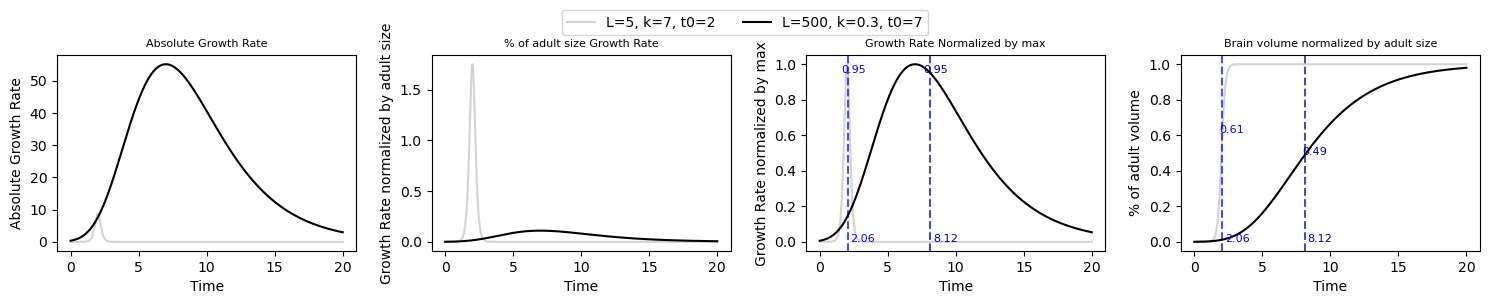

In [4]:
# Define parameters for the growth function
L_k_t0_combinations = [(5, 7, 2,"lightgrey",growth_logistic,growth_rate_logistic), 
                       (500, 0.3, 7,"black",growth_Gompertz,growth_rate_Gompertz)]  # Combinations of L, k, and t0, color, birth time

# Generate time points
t = np.linspace(0, 20, 500)

#Plot
# Create a figure with 4 subplots
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15, 3))


# Plot the absolute growth rate curves (left column, bottom)
for L, k, t0, color, growth_func, deriv_func in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = deriv_func(t, k, t0, L)
    ax[0].plot(t, y, color = color,label=f'L={L}, k={k}, t0={t0}')
    #t_birth = t0 + t_birth_delay  # Calculate the birth time based on t0 and delay
    #ax[0, 1].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

# Plot the normalized growth rate curves (right column, bottom)
for L, k, t0, color, growth_func, deriv_func in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = deriv_func(t, k, t0, L) / L  # Normalize by L
    ax[1].plot(t, y,color = color, label=f'L={L}, k={k}, t0={t0}')
    #t_birth = t0 + t_birth_delay  # Calculate the birth time based on t0 and delay
    #ax[0, 2].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

birth_days = {"x_shift":[], "y_shift":[]}


#Same shift in y
y_value_shift = 0.05
colors_shift_y = ["blue","darkblue"]
i = 0
for L, k, t0, color, growth_func, deriv_func in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = deriv_func(t, k, t0, L)/ np.max(deriv_func(t, k, t0, L))  # Normalize by max growth rate
    ax[2].plot(t, y, color = color,label=f'L={L}, k={k}, t0={t0}')

    
    FOUND = False
    t_birth = t0 
    while not FOUND:
        t_birth += 0.001  # Calculate the birth time based on t0 and delay
        y_at_birth = deriv_func(t_birth, k, t0, L) / np.max(deriv_func(t, k, t0, L))
        distance_from_value = np.abs(1-y_value_shift - y_at_birth)

        if  distance_from_value < 0.001:
            ax[2].text(t_birth - 0.5, y_at_birth, f'{y_at_birth:.2f}', color=colors_shift_y[i], fontsize=8)
            ax[2].axvline(x=t_birth, color=colors_shift_y[i], linestyle='--', alpha=0.7)
            ax[2].text(t_birth + 0.2, 0, f'{t_birth:.2f}', color=colors_shift_y[i], fontsize=8)
            birth_days["y_shift"].append(t_birth)
            FOUND = True
        
    i += 1


i = 0
# Plot the normalized growth curves (right column, top)
for L, k, t0, color, growth_func, deriv_func in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = growth_func(t, k, t0, L) / L  # Normalize by L
    ax[3].plot(t, y,color = color, label=f'L={L}, k={k}, t0={t0}')

    t_birth = birth_days["y_shift"][i]  # Calculate the birth time based on t0 and delay
    ax[3].axvline(x=t_birth, color=colors_shift_y[i], linestyle='--', alpha=0.7)
    y_at_birth = growth_func(t_birth, k, t0, L) / L
    ax[3].text(t_birth - 0.2, y_at_birth, f'{y_at_birth:.2f}', color=colors_shift_y[i], fontsize=8)
    ax[3].text(t_birth + 0.2, 0, f'{t_birth:.2f}', color=colors_shift_y[i], fontsize=8)


    i += 1

# Set titles and labels
ax[0].set_title('Absolute Growth Rate', fontsize=8)
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Absolute Growth Rate')

ax[1].set_title('% of adult size Growth Rate', fontsize=8)
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Growth Rate normalized by adult size')

ax[2].set_title('Growth Rate Normalized by max', fontsize=8)
ax[2].set_xlabel('Time')
ax[2].set_ylabel('Growth Rate normalized by max')

ax[3].set_title('Brain volume normalized by adult size', fontsize=8)
ax[3].set_xlabel('Time')
ax[3].set_ylabel('% of adult volume')


# Add a single legend for the entire figure
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the legend

# Save the figure
fig.savefig("{0}/figs/2D_E_F_G_2.pdf".format(PYTHON_PATH), dpi=800)

plt.show()

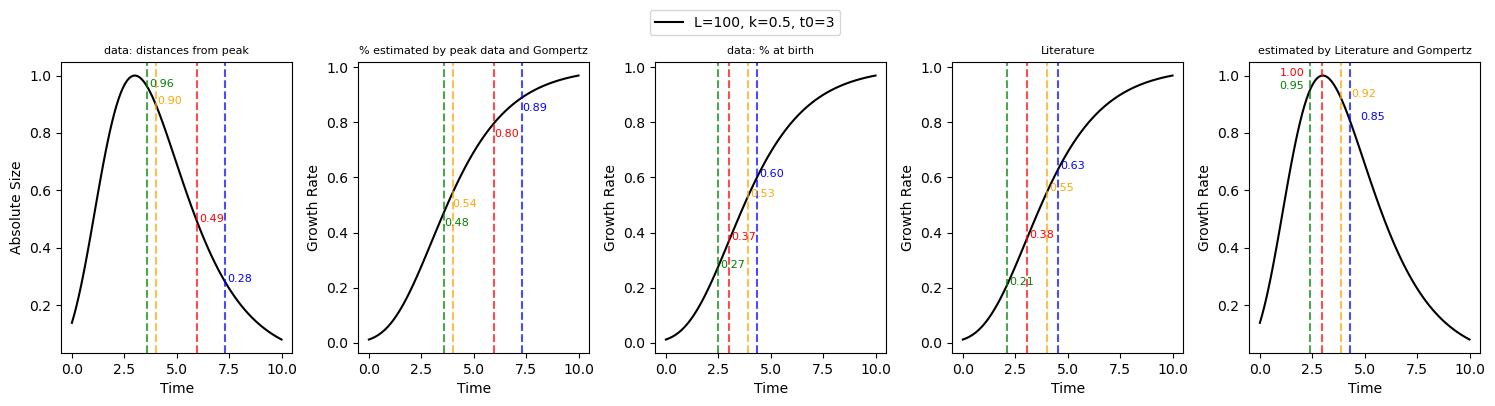

In [7]:
# Define parameters for the growth function
t_birth_delay = 0.2
L_k_t0_combinations = [(100, 0.5, 3,"black")]  # Combinations of L, k, and t0, color, birth time

# Generate time points
t = np.linspace(0, 10, 100)

#Plot
# Create a figure with 4 subplots
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15, 4))

# Plot the absolute growth curves (left column, top)

distances_from_peak = [0.04,0.1,0.51,0.72] #order: human, marmoset, chimpanzee, rhesus
colors_shift_y = ["green","orange","red","blue"]
L, k, t0, color = L_k_t0_combinations[0]  # Use the first combination for birth time calculations

save_birth_times = []  # List to store birth times for each combination

for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = growth_rate_Gompertz(t, k, t0, L)/ np.max(growth_rate_Gompertz(t, k, t0, L))  # Normalize by max growth rate
    ax[0].plot(t, y, color = color,label=f'L={L}, k={k}, t0={t0}')
    #t_birth = t0 + t_birth_delay  # Calculate the birth time based on t0 and delay
    #ax[0, 1].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)
    i=0
    for y_value_shift in distances_from_peak:  # Iterate over the distances from peak
        FOUND = False
        t_birth = t0 
        while not FOUND:
            t_birth += 0.001  # Calculate the birth time based on t0 and delay
            y_at_birth = growth_rate_Gompertz(t_birth, k, t0, L) / np.max(growth_rate_Gompertz(t, k, t0, L))
            distance_from_value = np.abs(1-y_value_shift - y_at_birth)

            if  distance_from_value < 0.001:
                ax[0].text(t_birth + 0.1, y_at_birth, f'{y_at_birth:.2f}', color=colors_shift_y[i], fontsize=8)
                ax[0].axvline(x=t_birth, color=colors_shift_y[i], linestyle='--', alpha=0.7)
                save_birth_times.append(t_birth)
                #ax[0].text(t_birth + 0.2, 0, f'{t_birth:.2f}', color=colors_shift_y[i], fontsize=8)
                FOUND = True
        i += 1


i = 0
for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = growth_Gompertz(t, k, t0, L)/L
    ax[1].plot(t, y, color = color, label=f'L={L}, k={k}, t0={t0}')
    for color in colors_shift_y:
        t_birth = save_birth_times[i]
        ax[1].axvline(x=t_birth, color=color, linestyle='--', alpha=0.7)
        y_at_birth = growth_Gompertz(t_birth, k, t0, L)/L
        ax[1].text(t_birth, y_at_birth - 0.05, f'{y_at_birth:.2f}', color=color, fontsize=8)

        i += 1



i = 0
data_percent_at_birth = [28,54,38,61]
for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = growth_Gompertz(t, k, t0, L)/L
    ax[2].plot(t, y, color = color, label=f'L={L}, k={k}, t0={t0}')
    for percent_birth in data_percent_at_birth:  # Iterate over the distances from peak
        FOUND = False
        t_birth = 0 
        while not FOUND and t_birth <10:
            t_birth += 0.01  # Calculate the birth time based on t0 and delay
            y_at_birth = growth_Gompertz(t_birth, k, t0, L)/L
            distance_from_value = np.abs(percent_birth/100 - y_at_birth)

            if  distance_from_value < 0.01:
                ax[2].text(t_birth + 0.1, y_at_birth, f'{y_at_birth:.2f}', color=colors_shift_y[i], fontsize=8)
                ax[2].axvline(x=t_birth, color=colors_shift_y[i], linestyle='--', alpha=0.7)
                save_birth_times.append(t_birth)
                #ax[0].text(t_birth + 0.2, 0, f'{t_birth:.2f}', color=colors_shift_y[i], fontsize=8)
                FOUND = True

        i += 1


i = 0

data_percent_at_birth = [22,56,39,64]
#rhesus: Total brain volume was about 64 % of adult estimates in the 1-week-old monkey.  Longitudinal analysis of the developing rhesus monkey brain using magnetic resonance imaging: birth to adulthood, 2015
#chimpanzee: Using these averages, chimpanzees achieve 39.5% of their brain growth by birth. Chimpanzee neonatal brain size: Implications for brain growth in Homo erectus, 2006
#human:
#marmoset:
for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = growth_Gompertz(t, k, t0, L)/L
    ax[3].plot(t, y, color = color, label=f'L={L}, k={k}, t0={t0}')
    for percent_birth in data_percent_at_birth:  # Iterate over the distances from peak
        FOUND = False
        t_birth = 0 
        while not FOUND and t_birth <10:
            t_birth += 0.01  # Calculate the birth time based on t0 and delay
            y_at_birth = growth_Gompertz(t_birth, k, t0, L)/L
            distance_from_value = np.abs(percent_birth/100 - y_at_birth)

            if  distance_from_value < 0.01:
                ax[3].text(t_birth + 0.1, y_at_birth, f'{y_at_birth:.2f}', color=colors_shift_y[i], fontsize=8)
                ax[3].axvline(x=t_birth, color=colors_shift_y[i], linestyle='--', alpha=0.7)
                save_birth_times.append(t_birth)
                #ax[0].text(t_birth + 0.2, 0, f'{t_birth:.2f}', color=colors_shift_y[i], fontsize=8)
                FOUND = True

        i += 1


i = 0

data_percent_at_birth = [27,53,37,60]
where_to_plot = [1.5,-0.5,2,-0.5]  # Adjust the x-axis position for each species
for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = growth_rate_Gompertz(t, k, t0, L)/ np.max(growth_rate_Gompertz(t, k, t0, L))  # Normalize by max growth rate
    ax[4].plot(t, y, color = color, label=f'L={L}, k={k}, t0={t0}')

    for percent_birth in data_percent_at_birth:  # Iterate over the distances from peak
        FOUND = False
        t_birth = 0 
        while not FOUND and t_birth <10:
            t_birth += 0.01  # Calculate the birth time based on t0 and delay
            y_at_birth = growth_Gompertz(t_birth, k, t0, L)/L
            distance_from_value = np.abs(percent_birth/100 - y_at_birth)

            y_rate_at_birth = growth_rate_Gompertz(t_birth, k, t0, L) / np.max(growth_rate_Gompertz(t, k, t0, L))
            if  distance_from_value < 0.01:
                ax[4].text(t_birth - where_to_plot[i], y_rate_at_birth, f'{y_rate_at_birth:.2f}', color=colors_shift_y[i], fontsize=8)
                ax[4].axvline(x=t_birth, color=colors_shift_y[i], linestyle='--', alpha=0.7)
                save_birth_times.append(t_birth)
                #ax[0].text(t_birth + 0.2, 0, f'{t_birth:.2f}', color=colors_shift_y[i], fontsize=8)
                FOUND = True

        i += 1


# Set titles and labels
FONTSIZE = 8
ax[0].set_title('data: distances from peak', fontsize=FONTSIZE)
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Absolute Size')

ax[1].set_title('% estimated by peak data and Gompertz', fontsize=FONTSIZE)
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Growth Rate')

ax[2].set_title('data: % at birth',fontsize=FONTSIZE)
ax[2].set_xlabel('Time')
ax[2].set_ylabel('Growth Rate')

ax[3].set_title('Literature',fontsize=FONTSIZE)
ax[3].set_xlabel('Time')
ax[3].set_ylabel('Growth Rate')


ax[4].set_title('estimated by Literature and Gompertz',fontsize=FONTSIZE)
ax[4].set_xlabel('Time')
ax[4].set_ylabel('Growth Rate')


# Add a single legend for the entire figure
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=5)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the legend


fig.savefig("{0}/figs/2D_E_F_G_data_correspondence.pdf".format(PYTHON_PATH), dpi=800)


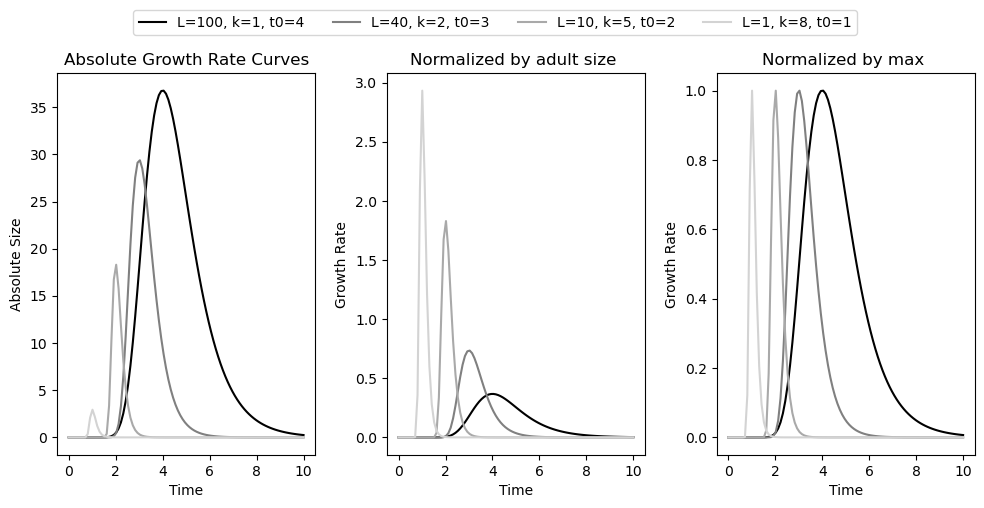

In [6]:
# Define parameters for the growth function
t_birth_delay = 0.2
L_k_t0_combinations = [(100, 1, 4,"black"),(40, 2, 3,"grey"),(10, 5, 2,"darkgrey"),(1, 8, 1,"lightgrey")]#,(1, 1, 1,"pink")]  # Combinations of L, k, and t0, color, birth time

# Generate time points
t = np.linspace(0, 10, 100)

#Plot
# Create a figure with 4 subplots
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))

# Plot the absolute growth curves (left column, top)
for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = growth_rate_Gompertz(t, k, t0, L)
    ax[0].plot(t, y, color = color, label=f'L={L}, k={k}, t0={t0}')
    #t_birth = t0 + t_birth_delay  # Calculate the birth time based on t0 and delay
    #ax[0, 0].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)


# Plot the absolute growth rate curves (left column, bottom)
for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = growth_rate_Gompertz(t, k, t0, L)/L
    ax[1].plot(t, y, color = color,label=f'L={L}, k={k}, t0={t0}')
    #t_birth = t0 + t_birth_delay  # Calculate the birth time based on t0 and delay
    #ax[0, 1].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)

for L, k, t0, color in L_k_t0_combinations:  # Iterate over L, k, and t0 combinations
    y = growth_rate_Gompertz(t, k, t0, L)/ np.max(growth_rate_Gompertz(t, k, t0, L))  # Normalize by max growth rate
    ax[2].plot(t, y, color = color,label=f'L={L}, k={k}, t0={t0}')
    #t_birth = t0 + t_birth_delay  # Calculate the birth time based on t0 and delay
    #ax[0, 1].axvline(x=t_birth, color='black', linestyle='--', alpha=0.7)


# Set titles and labels
ax[0].set_title('Absolute Growth Rate Curves')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Absolute Size')

ax[1].set_title('Normalized by adult size ')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Growth Rate')

ax[2].set_title('Normalized by max ')
ax[2].set_xlabel('Time')
ax[2].set_ylabel('Growth Rate')


# Add a single legend for the entire figure
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=5)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the legend